<a href="https://colab.research.google.com/github/sairamsrujan/celebal-excellence-internship/blob/main/Week5_RSaiRamSrujanKumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
# Colab setup: install tf-keras and use the classic tf.keras (Keras 2) API
!pip install -q tf-keras
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [3]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [5]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [6]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [7]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

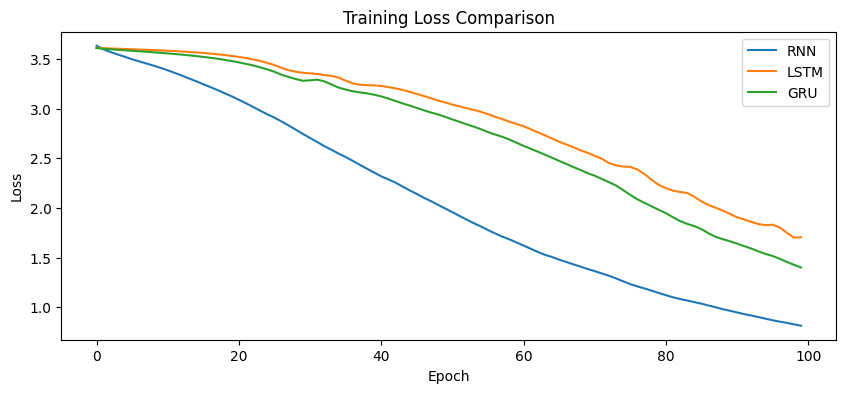

In [8]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [9]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [10]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning models models generate meaningful sentences
GRU : deep learning models transforming transforming intelligence intelligence


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

### Task 1: Custom Paragraph Corpus
I replace the small sample text with a much larger corpus of my own: about **500 lines from Shakespeare's *Romeo and Juliet*** . A big, real literary corpus like this gives the models a rich vocabulary and lots of sentence structure to learn from. I then rebuild the tokenizer and the n-gram sequences on it.



In [11]:
corpus = '''
two households both alike in dignity
in fair verona where we lay our scene
from ancient grudge break to new mutiny
where civil blood makes civil hands unclean
from forth the fatal loins of these two foes
a pair of star crossd lovers take their life
whose misadventurd piteous overthrows
doth with their death bury their parents strife
the fearful passage of their death markd love
and the continuance of their parents rage
which but their childrens end nought could remove
is now the two hours traffic of our stage
the which if you with patient ears attend
what here shall miss our toil shall strive to mend
gregory on my word well not carry coals
no for then we should be colliers
i mean if we be in choler well draw
ay while you live draw your neck out o the collar
i strike quickly being moved
but thou art not quickly moved to strike
a dog of the house of montague moves me
art moved thou runnst away
a dog of that house shall move me to stand
i will take the wall of any man or maid of montagues
true and therefore women being the weaker vessels are ever thrust to
the wall therefore i will push montagues men from the wall and
thrust his maids to the wall
the quarrel is between our masters and us their men
the heads of the maids
they must take it in sense that feel it
pretty piece of flesh
draw thy tool here comes of the house of montagues
my naked weapon is out quarrel i will back thee
how turn thy back and run
no marry i fear thee
let us take the law of our sides let them begin
them if they bear it
do you bite your thumb at us sir
i do bite my thumb sir
do you bite your thumb at us sir
is the law of our side if i say ay
do you quarrel sir
quarrel sir no sir
say better here comes one of my masters kinsmen
draw if you be men gregory remember thy washing blow
part fools put up your swords you know not what you do
what art thou drawn among these heartless hinds
turn thee benvolio look upon thy death
i do but keep the peace put up thy sword
or manage it to part these men with me
what drawn and talk of peace i hate the word
as i hate hell all montagues and thee
have at thee coward
clubs bills and partisans strike beat them down
down with the capulets down with the montagues
what noise is this give me my long sword ho
a crutch a crutch why call you for a sword
my sword i say old montague is come
and flourishes his blade in spite of me
thou villain capulet hold me not let me go
thou shalt not stir one foot to seek a foe
rebellious subjects enemies to peace
profaners of this neighbour stained steel
will they not hear what ho you men you beasts
that quench the fire of your pernicious rage
with purple fountains issuing from your veins
on pain of torture from those bloody hands
throw your mistemperd weapons to the ground
and hear the sentence of your moved prince
three civil brawls bred of an airy word
by thee old capulet and montague
have thrice disturbd the quiet of our streets
and made veronas ancient citizens
cast by their grave beseeming ornaments
to wield old partisans in hands as old
cankerd with peace to part your cankerd hate
if ever you disturb our streets again
your lives shall pay the forfeit of the peace
for this time all the rest depart away
you capulet shall go along with me
and montague come you this afternoon
to know our farther pleasure in this case
to old free town our common judgement place
once more on pain of death all men depart
who set this ancient quarrel new abroach
speak nephew were you by when it began
here were the servants of your adversary
and yours close fighting ere i did approach
i drew to part them in the instant came
the fiery tybalt with his sword prepard
which as he breathd defiance to my ears
he swung about his head and cut the winds
who nothing hurt withal hissd him in scorn
while we were interchanging thrusts and blows
came more and more and fought on part and part
till the prince came who parted either part
o where is romeo saw you him today
right glad i am he was not at this fray
madam an hour before the worshippd sun
peerd forth the golden window of the east
a troubled mind drave me to walk abroad
where underneath the grove of sycamore
that westward rooteth from this city side
so early walking did i see your son
towards him i made but he was ware of me
and stole into the covert of the wood
i measuring his affections by my own
which then most sought where most might not be found
being one too many by my weary self
pursud my humour not pursuing his
and gladly shunnd who gladly fled from me
many a morning hath he there been seen
with tears augmenting the fresh mornings dew
adding to clouds more clouds with his deep sighs
but all so soon as the all cheering sun
should in the farthest east begin to draw
the shady curtains from auroras bed
away from light steals home my heavy son
and private in his chamber pens himself
shuts up his windows locks fair daylight out
and makes himself an artificial night
black and portentous must this humour prove
unless good counsel may the cause remove
my noble uncle do you know the cause
i neither know it nor can learn of him
have you importund him by any means
both by myself and many other friends
but he his own affections counsellor
is to himself i will not say how true
but to himself so secret and so close
so far from sounding and discovery
as is the bud bit with an envious worm
ere he can spread his sweet leaves to the air
or dedicate his beauty to the sun
could we but learn from whence his sorrows grow
we would as willingly give cure as know
see where he comes so please you step aside
ill know his grievance or be much denied
i would thou wert so happy by thy stay
to hear true shrift come madam lets away
is the day so young
but new struck nine
ay me sad hours seem long
was that my father that went hence so fast
it was what sadness lengthens romeos hours
not having that which having makes them short
out of her favour where i am in love
alas that love so gentle in his view
should be so tyrannous and rough in proof
alas that love whose view is muffled still
should without eyes see pathways to his will
where shall we dine o me what fray was here
yet tell me not for i have heard it all
heres much to do with hate but more with love
why then o brawling love o loving hate
o anything of nothing first create
o heavy lightness serious vanity
misshapen chaos of well seeming forms
feather of lead bright smoke cold fire sick health
still waking sleep that is not what it is
this love feel i that feel no love in this
dost thou not laugh
no coz i rather weep
good heart at what
at thy good hearts oppression
why such is loves transgression
griefs of mine own lie heavy in my breast
which thou wilt propagate to have it prest
with more of thine this love that thou hast shown
doth add more grief to too much of mine own
love is a smoke made with the fume of sighs
being purgd a fire sparkling in lovers eyes
being vexd a sea nourishd with lovers tears
what is it else a madness most discreet
a choking gall and a preserving sweet
soft i will go along
and if you leave me so you do me wrong
tut i have lost myself i am not here
this is not romeo hes some other where
tell me in sadness who is that you love
what shall i groan and tell thee
groan why no but sadly tell me who
bid a sick man in sadness make his will
a word ill urgd to one that is so ill
in sadness cousin i do love a woman
i aimd so near when i supposd you lovd
a right good markman and shes fair i love
a right fair mark fair coz is soonest hit
well in that hit you miss shell not be hit
with cupids arrow she hath dians wit
and in strong proof of chastity well armd
from loves weak childish bow she lives uncharmd
she will not stay the siege of loving terms
nor bide thencounter of assailing eyes
nor ope her lap to saint seducing gold
o shes rich in beauty only poor
that when she dies with beauty dies her store
then she hath sworn that she will still live chaste
she hath and in that sparing makes huge waste
for beauty starvd with her severity
cuts beauty off from all posterity
she is too fair too wise wisely too fair
to merit bliss by making me despair
she hath forsworn to love and in that vow
do i live dead that live to tell it now
be ruld by me forget to think of her
o teach me how i should forget to think
by giving liberty unto thine eyes
to call hers exquisite in question more
these happy masks that kiss fair ladies brows
being black puts us in mind they hide the fair
he that is strucken blind cannot forget
the precious treasure of his eyesight lost
show me a mistress that is passing fair
what doth her beauty serve but as a note
where i may read who passd that passing fair
farewell thou canst not teach me to forget
ill pay that doctrine or else die in debt
but montague is bound as well as i
in penalty alike and tis not hard i think
for men so old as we to keep the peace
of honourable reckoning are you both
and pity tis you livd at odds so long
but now my lord what say you to my suit
but saying oer what i have said before
my child is yet a stranger in the world
she hath not seen the change of fourteen years
let two more summers wither in their pride
ere we may think her ripe to be a bride
younger than she are happy mothers made
and too soon marrd are those so early made
the earth hath swallowed all my hopes but she
she is the hopeful lady of my earth
but woo her gentle paris get her heart
my will to her consent is but a part
and she agree within her scope of choice
lies my consent and fair according voice
this night i hold an old accustomd feast
whereto i have invited many a guest
such as i love and you among the store
one more most welcome makes my number more
at my poor house look to behold this night
earth treading stars that make dark heaven light
such comfort as do lusty young men feel
when well apparelld april on the heel
of limping winter treads even such delight
among fresh female buds shall you this night
inherit at my house hear all all see
and like her most whose merit most shall be
which on more view of many mine being one
may stand in number though in reckoning none
come go with me go sirrah trudge about
through fair verona find those persons out
whose names are written there gives a paper and to them say
my house and welcome on their pleasure stay
tut man one fire burns out anothers burning
one pain is lessend by anothers anguish
turn giddy and be holp by backward turning
one desperate grief cures with anothers languish
take thou some new infection to thy eye
and the rank poison of the old will die
your plantain leaf is excellent for that
for what i pray thee
for your broken shin
why romeo art thou mad
not mad but bound more than a madman is
shut up in prison kept without my food
whippd and tormented and god den good fellow
god gi go den i pray sir can you read
ay mine own fortune in my misery
perhaps you have learned it without book
but i pray can you read anything you see
ay if i know the letters and the language
ye say honestly rest you merry
stay fellow i can read
signior martino and his wife and daughters
county anselmo and his beauteous sisters
the lady widow of utruvio
signior placentio and his lovely nieces
mercutio and his brother valentine
mine uncle capulet his wife and daughters
my fair niece rosaline and livia
signior valentio and his cousin tybalt
lucio and the lively helena
a fair assembly gives back the paper whither should they come
indeed i should have askd you that before
cup of wine rest you merry
at this same ancient feast of capulets
sups the fair rosaline whom thou so lovst
with all the admired beauties of verona
go thither and with unattainted eye
compare her face with some that i shall show
and i will make thee think thy swan a crow
when the devout religion of mine eye
maintains such falsehood then turn tears to fire
and these who often drownd could never die
transparent heretics be burnt for liars
one fairer than my love the all seeing sun
neer saw her match since first the world begun
tut you saw her fair none else being by
herself poisd with herself in either eye
but in that crystal scales let there be weighd
your ladys love against some other maid
that i will show you shining at this feast
and she shall scant show well that now shows best
ill go along no such sight to be shown
but to rejoice in splendour of my own
nurse wheres my daughter call her forth to me
now by my maidenhead at twelve year old
i bade her come what lamb what ladybird
god forbid wheres this girl what juliet
how now who calls
madam i am here what is your will
this is the matter nurse give leave awhile
we must talk in secret nurse come back again
i have rememberd me thous hear our counsel
thou knowest my daughters of a pretty age
faith i can tell her age unto an hour
ill lay fourteen of my teeth
and yet to my teen be it spoken i have but four
she is not fourteen how long is it now
a fortnight and odd days
even or odd of all days in the year
come lammas eve at night shall she be fourteen
susan and she god rest all christian souls
were of an age well susan is with god
she was too good for me but as i said
on lammas eve at night shall she be fourteen
that shall she marry i remember it well
tis since the earthquake now eleven years
and she was weand i never shall forget it
of all the days of the year upon that day
for i had then laid wormwood to my dug
sitting in the sun under the dovehouse wall
my lord and you were then at mantua
nay i do bear a brain but as i said
when it did taste the wormwood on the nipple
of my dug and felt it bitter pretty fool
to see it tetchy and fall out with the dug
shake quoth the dovehouse twas no need i trow
to bid me trudge
and since that time it is eleven years
for then she could stand alone nay by throod
she could have run and waddled all about
for even the day before she broke her brow
and then my husband god be with his soul
a was a merry man took up the child
yea quoth he dost thou fall upon thy face
thou wilt fall backward when thou hast more wit
wilt thou not jule and by my holidame
the pretty wretch left crying and said ay
to see now how a jest shall come about
i warrant and i should live a thousand years
i never should forget it wilt thou not jule quoth he
and pretty fool it stinted and said ay
enough of this i pray thee hold thy peace
yes madam yet i cannot choose but laugh
to think it should leave crying and say ay
and yet i warrant it had upon it brow
a bump as big as a young cockerels stone
a perilous knock and it cried bitterly
yea quoth my husband fallst upon thy face
thou wilt fall backward when thou comest to age
wilt thou not jule it stinted and said ay
and stint thou too i pray thee nurse say i
peace i have done god mark thee to his grace
thou wast the prettiest babe that eer i nursd
marry that marry is the very theme
i came to talk of tell me daughter juliet
how stands your disposition to be married
it is an honour that i dream not of
an honour were not i thine only nurse
i would say thou hadst suckd wisdom from thy teat
well think of marriage now younger than you
here in verona ladies of esteem
are made already mothers by my count
i was your mother much upon these years
that you are now a maid thus then in brief
the valiant paris seeks you for his love
a man young lady lady such a man
as all the world why hes a man of wax
veronas summer hath not such a flower
nay hes a flower in faith a very flower
what say you can you love the gentleman
this night you shall behold him at our feast
read oer the volume of young paris face
and find delight writ there with beautys pen
examine every married lineament
and see how one another lends content
and what obscurd in this fair volume lies
find written in the margent of his eyes
this precious book of love this unbound lover
to beautify him only lacks a cover
the fish lives in the sea and tis much pride
for fair without the fair within to hide
that book in manys eyes doth share the glory
that in gold clasps locks in the golden story
so shall you share all that he doth possess
by having him making yourself no less
no less nay bigger women grow by men
speak briefly can you like of paris love
ill look to like if looking liking move
but no more deep will i endart mine eye
than your consent gives strength to make it fly
asked for the nurse cursed in the pantry and everything in extremity
i must hence to wait i beseech you follow straight
juliet the county stays
go girl seek happy nights to happy days
torch bearers and others
what shall this speech be spoke for our excuse
or shall we on without apology
the date is out of such prolixity
well have no cupid hoodwinkd with a scarf
bearing a tartars painted bow of lath
scaring the ladies like a crow keeper
nor no without book prologue faintly spoke
after the prompter for our entrance
but let them measure us by what they will
well measure them a measure and be gone
give me a torch i am not for this ambling
being but heavy i will bear the light
nay gentle romeo we must have you dance
not i believe me you have dancing shoes
with nimble soles i have a soul of lead
so stakes me to the ground i cannot move
you are a lover borrow cupids wings
and soar with them above a common bound
i am too sore enpierced with his shaft
to soar with his light feathers and so bound
i cannot bound a pitch above dull woe
under loves heavy burden do i sink
and to sink in it should you burden love
too great oppression for a tender thing
is love a tender thing it is too rough
too rude too boisterous and it pricks like thorn
if love be rough with you be rough with love
prick love for pricking and you beat love down
a visor for a visor what care i
what curious eye doth quote deformities
here are the beetle brows shall blush for me
come knock and enter and no sooner in
but every man betake him to his legs
a torch for me let wantons light of heart
tickle the senseless rushes with their heels
for i am proverbd with a grandsire phrase
ill be a candle holder and look on
the game was neer so fair and i am done
tut duns the mouse the constables own word
if thou art dun well draw thee from the mire
or save your reverence love wherein thou stickest
up to the ears come we burn daylight ho
nay thats not so
i mean sir in delay
we waste our lights in vain light lights by day
take our good meaning for our judgment sits
five times in that ere once in our five wits
and we mean well in going to this mask
but tis no wit to go
why may one ask
i dreamt a dream tonight
and so did i
well what was yours
that dreamers often lie
in bed asleep while they do dream things true
o then i see queen mab hath been with you
she is the fairies midwife and she comes
in shape no bigger than an agate stone
on the fore finger of an alderman
drawn with a team of little atomies
over mens noses as they lie asleep
her waggon spokes made of long spinners legs
the cover of the wings of grasshoppers
her traces of the smallest spiders web
the collars of the moonshines watery beams
her whip of crickets bone the lash of film
her waggoner a small grey coated gnat
not half so big as a round little worm
prickd from the lazy finger of a maid
her chariot is an empty hazelnut
made by the joiner squirrel or old grub
time out o mind the fairies coachmakers
and in this state she gallops night by night
through lovers brains and then they dream of love
oer courtiers knees that dream on curtsies straight
oer lawyers fingers who straight dream on fees
oer ladies lips who straight on kisses dream
which oft the angry mab with blisters plagues
because their breaths with sweetmeats tainted are
sometime she gallops oer a courtiers nose
and then dreams he of smelling out a suit
and sometime comes she with a tithe pigs tail
tickling a parsons nose as a lies asleep
then dreams he of another benefice
sometime she driveth oer a soldiers neck
and then dreams he of cutting foreign throats
of breaches ambuscados spanish blades
of healths five fathom deep and then anon
drums in his ear at which he starts and wakes
and being thus frighted swears a prayer or two
and sleeps again this is that very mab
'''

tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Total lines:", len([l for l in corpus.split('\n') if l.strip()]))
print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 1247
Total lines: 500
X shape: (3474, 11)
y shape: (3474,)


### Looking at the tokenizer and the sequences
A quick look at how each word is mapped to a number, and what the n-gram sequences look like when turned back into words.

In [12]:
# show the first few word -> index mappings
print("Vocabulary size:", total_words)
print("First 20 word -> index pairs:")
print(dict(list(tokenizer.word_index.items())[:20]))

# show a few n-gram sequences as words (skipping the padding zeros)
index_word = {index: word for word, index in tokenizer.word_index.items()}
print("\nExample n-gram sequences:")
for seq in input_sequences[:5]:
    words = [index_word[i] for i in seq if i != 0]
    print(words)

Vocabulary size: 1247
First 20 word -> index pairs:
{'the': 1, 'and': 2, 'of': 3, 'i': 4, 'a': 5, 'to': 6, 'in': 7, 'you': 8, 'that': 9, 'with': 10, 'is': 11, 'my': 12, 'me': 13, 'not': 14, 'it': 15, 'his': 16, 'but': 17, 'she': 18, 'this': 19, 'love': 20}

Example n-gram sequences:
['two', 'households']
['two', 'households', 'both']
['two', 'households', 'both', 'alike']
['two', 'households', 'both', 'alike', 'in']
['two', 'households', 'both', 'alike', 'in', 'dignity']


### Tasks 2, 3 & 4: Bigger Embedding, More Epochs, Wider Layers
Increasing the embedding dimension to 100, training for 200 epochs, and using 128 hidden units in each model. I also record how long each model takes to train.

In [13]:
import time

rnn_model2 = Sequential([
    Embedding(total_words, 100, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])
rnn_model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
start = time.time()
rnn_history2 = rnn_model2.fit(X, y, epochs=200, verbose=0)
rnn_time2 = time.time() - start

lstm_model2 = Sequential([
    Embedding(total_words, 100, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
start = time.time()
lstm_history2 = lstm_model2.fit(X, y, epochs=200, verbose=0)
lstm_time2 = time.time() - start

gru_model2 = Sequential([
    Embedding(total_words, 100, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
start = time.time()
gru_history2 = gru_model2.fit(X, y, epochs=200, verbose=0)
gru_time2 = time.time() - start

print("Training with new settings completed")
print("Final accuracy - RNN:", round(rnn_history2.history['accuracy'][-1], 3),
      "| LSTM:", round(lstm_history2.history['accuracy'][-1], 3),
      "| GRU:", round(gru_history2.history['accuracy'][-1], 3))

Training with new settings completed
Final accuracy - RNN: 0.894 | LSTM: 0.893 | GRU: 0.894


### Model Architectures
The summary of each model shows its layers and the number of parameters. The LSTM has the most parameters because of its extra gates, the GRU has fewer, and the simple RNN has the fewest.

In [14]:
print("RNN model:")
rnn_model2.summary()
print("\nLSTM model:")
lstm_model2.summary()
print("\nGRU model:")
gru_model2.summary()

RNN model:
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 11, 100)           124700    
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 128)               29312     
                                                                 
 dense_3 (Dense)             (None, 1247)              160863    
                                                                 
Total params: 314875 (1.20 MB)
Trainable params: 314875 (1.20 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

LSTM model:
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_4 (Embedding)     (None, 11, 100)           124700    
                                      

### Compare Training Loss (200 epochs)

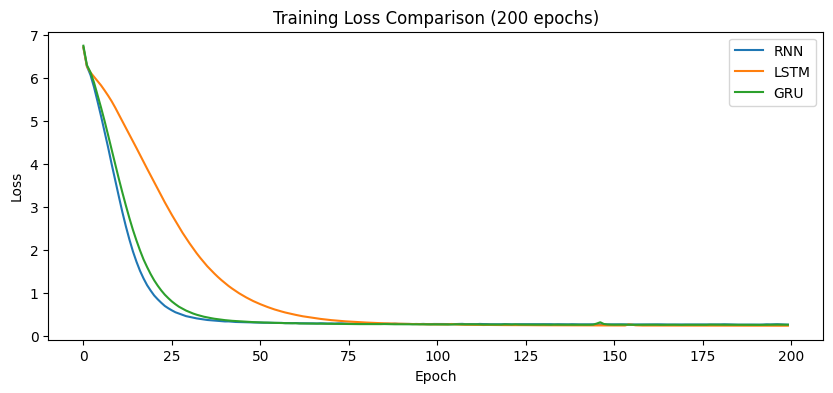

In [15]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history2.history['loss'], label='RNN')
plt.plot(lstm_history2.history['loss'], label='LSTM')
plt.plot(gru_history2.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (200 epochs)")
plt.legend()
plt.show()

### Compare Training Accuracy (200 epochs)

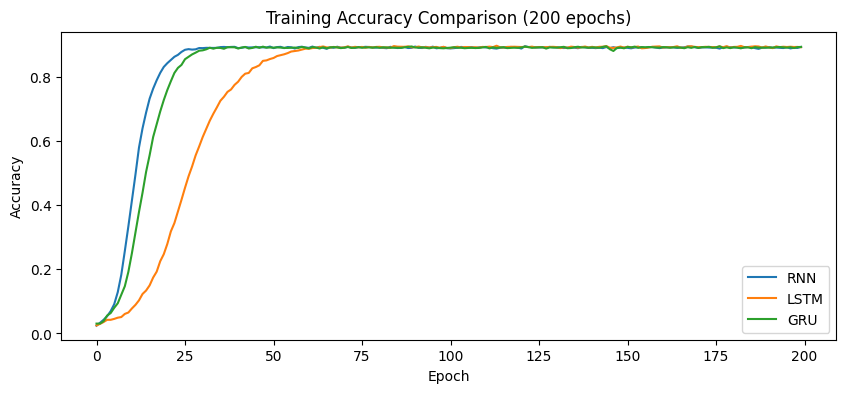

In [16]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history2.history['accuracy'], label='RNN')
plt.plot(lstm_history2.history['accuracy'], label='LSTM')
plt.plot(gru_history2.history['accuracy'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison (200 epochs)")
plt.legend()
plt.show()

### Model Comparison Table
Putting the three models side by side: number of parameters, final loss and accuracy, perplexity (the exponent of the loss), training time, and the first epoch where the loss dropped below 1.0.

In [17]:
import pandas as pd

def first_epoch_below(history, threshold=1.0):
    for i, loss in enumerate(history.history['loss']):
        if loss < threshold:
            return i + 1
    return None

results = {
    'RNN':  (rnn_model2,  rnn_history2,  rnn_time2),
    'LSTM': (lstm_model2, lstm_history2, lstm_time2),
    'GRU':  (gru_model2,  gru_history2,  gru_time2),
}

rows = []
for name, (model, history, train_time) in results.items():
    final_loss = history.history['loss'][-1]
    rows.append({
        'Model': name,
        'Parameters': model.count_params(),
        'Final loss': round(final_loss, 4),
        'Final accuracy': round(history.history['accuracy'][-1], 3),
        'Perplexity': round(float(np.exp(final_loss)), 2),
        'Training time (s)': round(train_time, 2),
        'Epoch loss<1.0': first_epoch_below(history),
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
metrics_df

,Parameters,Final loss,Final accuracy,Perplexity,Training time (s),Epoch loss<1.0
Model,,,,,,
RNN,314875,0.2657,0.894,1.30,292.27,21
LSTM,402811,0.2417,0.893,1.27,132.04,45
GRU,373883,0.2639,0.894,1.30,128.48,24


### Observations
- **Parameters:** the LSTM has the most parameters because it uses three gates, the GRU has fewer (two gates), and the simple RNN has the fewest. This ordering is always the same and is clear in the table.
- **Perplexity:** perplexity is just the exponent of the loss, so a lower loss always means a lower perplexity, which means the model is more confident about the next word.
- **Convergence and final loss:** the "Epoch loss<1.0" column shows how quickly each model brought its loss under 1.0. On a corpus this large the models take more epochs to fit the text than on a tiny sample.
- **Training time:** how long each model takes depends on the hardware. On a GPU the LSTM and GRU often train faster because Keras runs them on optimized cuDNN kernels, while on a CPU the simpler RNN is usually quickest. The table above shows the times measured in this run.
- **Generated text:** because the corpus is large and we decode greedily (np.argmax), the output is Shakespeare-style text that follows the patterns the model has learned, rather than an exact memorised line.

### Task 5: Generate 10 Words
Generating 10 words from a few different seed phrases (taken from the play) with each of the new models.

In [18]:
# Task 5: generate 10 words from a few different seed phrases
seeds = ["two households both", "o then i see", "from forth the fatal"]
for seed in seeds:
    print("Seed:", seed)
    print("  RNN :", generate_text(rnn_model2, seed, 10))
    print("  LSTM:", generate_text(lstm_model2, seed, 10))
    print("  GRU :", generate_text(gru_model2, seed, 10))
    print()

Seed: two households both
  RNN : two households both alike in dignity to part and in the mouse the
  LSTM: two households both alike in dignity days in be hit old glad do
  GRU : two households both alike in dignity eyes doth share them own come thumb

Seed: o then i see
  RNN : o then i see queen mab hath been with you with patient ears attend
  LSTM: o then i see queen mab hath been with you strike move down with
  GRU : o then i see queen mab hath been with you that when well measure

Seed: from forth the fatal
  RNN : from forth the fatal loins of these two foes deep sighs then a maid
  LSTM: from forth the fatal loins of these two foes foes then say say say
  GRU : from forth the fatal loins of these two foes foes foes wits wits of



# ✅ Conclusion
- On the Romeo and Juliet corpus all three models reached a similar accuracy (around 89%), so on a dataset of this size they performed comparably.
- The LSTM reached the lowest loss and perplexity, the GRU was very close with fewer parameters, and the simple RNN kept up well on this structured text.
- The real advantage of the gates in LSTM and GRU shows up on longer, harder text with long-range dependencies; on a corpus this size the simpler RNN can still do well.
- Increasing the embedding size to 100, the hidden units to 128, and training for 200 epochs let all three models generate fluent Shakespeare-style text.